<a href="https://colab.research.google.com/github/carmenbonal/2526_Computacional/blob/main/voluntario2/Voluntario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelo de Hopfield de red neuronal**

**1. Resumen**

En este ejercicio, simularemos el modelo de Hopfield de red neuronal, mediante el uso del algoritmo de Metrópolis. El objetivo es analizar el comportamiento de una red cuadrada bidimensional con condiciones de contorno periódicas, actuando como una memoria asociativa. Para ello, se implementa la regla de aprendizaje de Hebb, para almacenar múltiples patrones, y se evalúa la capacidad de la red para recuperarlos a partir de condiciones iniciales aleatorias y configuraciones deformadas.

**2. Fundamento Teórico**

**2.1 El Modelo de Hopfield**
El modelo de Hopfield describe una red neuronal totalmente corectada, donde cada nodo representa una neurona, la cual puede estar en un estado activo ($s_{i,j}=1$) o inactivo ($s_{i,j}=0$).
Físicamente, se describe con el siguiente Hamiltoniano:
$$H(s)=-\frac{1}{2}\sum_{i,j}\sum_{k,l}\omega_{ij,kl}s_{i,j}s_{k,l}+\sum_{i,j}\theta_{i,j}s_{i,j}$$

Donde $\omega_{ij,kl}$ son los pesos sinápticos que definen la fuerza de conexión entre neuronas, y $\theta_{i,j}$ es el umbral de disparo, que determina la sensibilidad de cada neurona ante el campo local de sus vecinas.

**2.2 Almacenamiento y Regla de Hebb**

Para que la red funcione como memoria, los patrones deseados ($\xi^\mu$) deben convertirse en mínimos locales de energía del Hamiltoniano. Esto se logra mediante la definición de pesos sinápticos según la actividad media de los patrones ($a^\mu$):
 $$\omega_{ij,kl} = \frac{1}{N^2} \sum_{\mu=1}^P (\xi_{i,j}^\mu - a^\mu)(\xi_{k,l}^\mu - a^\mu)$$

 Bajo esta configuración, no se permiten autoconexiones ($\omega_{ij,ij}=0$), lo que asegura que la dinámica sea estable y converja hacia los estados almacenados.

 **2.3 Algoritmo de Metrópolis y Temperatura**

 La evolución temporal de la red se simula mediante el algoritmo de Metrópolis, que introduce fluctuaciones térmicas en el sistema. La probabilidad de que una neurona cambie de estado viene dada por:

 $$p_{s\rightarrow s^{\prime}}=\min(1, e^{-\Delta H/T})$$

 Donde $\Delta H$ es la variación de energía al invertir el estado de una neurona.



*   A temperaturas bajas, el sistema actúa de forma determinista, buscando el mínimo de energías mas cercano.
*   A temperaturas altas, el desorden térmico impide que la red se estabilice en los patrones, provocando una transición de fase hacia un estado de ruido.


**2.4 Solapamiento y Capacidad Crítica**

Para cuantificar la fidelidad del recuerdo, definimos el solapamiento $m^\mu$), una magnitud acotada en $[-1, 1]$. Un valor de $m^\mu = 1$ indica una recuperación perfecta, mientras que $m^\mu = -1$ representa el antipatrón, donde todas las neuronas están invertidas respecto al original. Se calcula con la siguiente expresión:
$$m^\mu(s) = \frac{1}{N^2 a^\mu (1 - a^\mu)} \sum_{i,j} (\xi_{i,j}^\mu - a^\mu)(s_{i,j} - a^\mu)$$

La red tiene un límite en la cantidad de información que puede procesar. Definimos la fracción de carga como $\alpha = P/N^2$. Cuando el número de patrones P supera el valor crítico $P_c$, la interferencia entre memorias destruye los atractores del sistema, resultando en una caída abrupta del solapamiento, definida como amnesia catastrófica.



**3. Tareas**

**Tarea 1: Recueración de un único patrón**

El objetico es verificar que la red funciona como una memoria asociativa básica. Utilizaremos una red de $N=30$ (900 neuronas), y una temperatura muy baja ($T=10^{-4}$) para minimizar el ruido térmico.

*Condiciones iniciales:*


1.   Aleatoria: Iniciamos  la red en un estado totalmente aleatorio, para ver si es capaz de llegar al patrón guardado.
2.   Patrón deformado: Partimos del patrón original, pero con un porcentaje de las neuronas cambiadas, para estudiar la capacidad de autocorrección de la red.

Calcularemos el solapamiento en función del tiempo (pasos Monte Carlo) para cuantificar la velocidad y eficacia con la que la red "recuerda."


**Tarea 2: Influencia de la Temperatura**

Analizamos la estabilidad de la memoria frente a la agitación térmica. Para ello, repetiremos el proceso de la Tarea 1, pero variando el valor de T, con el objetivo de obtener una curva de solapamiento frente a la temperatura. Observaremos que, por encima de una temperatura crítica, el desorden térmico impide que las neuronas se estabilice, y el solapamiento decarerá a cero.

**Tarea 3: Multi-memoria y estados espúreos**

Almacenaremos varios patrones simultáneamente (P>1). Calcularemos $m^{\mu}(s)$ para cada patrón almacenado. También identificaremos cuando la red converge a un solapamiento de -1, lo que indica que la red ha recuperado el antipatrón, que también es un mínimo del Hamiltoniano.


**Tarea 4: Capacidad crítica**

El objetivo es determinar el límite máximo de información que la red puede procesar antes de que la recuperación de patrones sea inviable. Empleamos patrones aleatorios, para evitar que la correlaciones espaciales sesguen los resultados estadísticos. Se define que un patrón se "recuerda" si, tras la dinámica de Metrópolis, el solapamiento final es $m^{\mu}(s) > 0.75$.

La eficiencia de la red se cuantifica mediante la fracción crítica
$\alpha_c$, definida como:$$\alpha_c = \frac{P_c}{N^2}$$

Se observará un colapso en la gráfica, que representa la amnesia catastrófica, donde el sistema pierde la capacidad asociativa al saturarse de información.

 **3. Herramientas**

Este proyecto se ha realizado con el uso del modelo de lenguaje Gemini, como asistente para el desarrollo, depuración y optimización del código.

Siguiendo las indicaciones de las presentaciones, se priorizó un código "limpio", evitando el uso de librerías poco comunes o demasiado complejas. Se emplearon NumPy para la manipulación de vectores y matrices, y Numba, para la compilación de alto rendimiento.

**4. Código**

Primero importamos las librerías necesarias para completar la simulación.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import os

# --- CONFIGURACIÓN DE RUTA ---
PATH = r"C:\Users\Usuario\Desktop\2526_Computacional\voluntario2"
if not os.path.exists(PATH):
    os.makedirs(PATH)


Creamos una Clase 'HopfieldNet', una rejilla de $N \times N$ neuronas. Cada neurona puede estar activa ($s_{i,j}=1$) o inactiva ($s_{i,j}=0$).  

Aquí es donde la red "aprende". Se utiliza la regla de Hebb para definir las conexiones (pesos sinápticos) entre neuronas. Como restricción, no se permiten las autoconexiones ($\omega_{ij,ij}=0$), lo que evita que una neurona se retroalimente a sí misma de forma trivial.

También calculamos el solapamiento (overlap) $m^\mu$, el cual mide la similitud entre el estado actual de la red y un patrón guardado.

Para recuperar un recuerdo, la red debe evolucionar hacia un mínimo de energía (hamiltoniano). Para ello implementamos el algoritmo de Metrópolis, para simular esta evolución a cierta temperatura T.

In [11]:
class HopfieldNet:
    def __init__(self, N):
        self.N = N
        self.num_neurons = N * N
        self.w = None
        self.theta = None
        self.patterns = []
        self.a = []

    def store_patterns(self, p_list):
        # Construye la matriz de pesos sinápticos usando la regla de Hebb.
        self.patterns = [p.flatten() for p in p_list]
        self.a = [np.mean(p) for p in self.patterns] # a^mu: actividad media
        self.w = np.zeros((self.num_neurons, self.num_neurons)) #w: peso sináptico

        # Optimización: Calculamos la matriz de pesos de una sola vez usando operaciones vectorizadas
        # Nota: El producto exterior (outer) suma la correlación de cada par de neuronas para cada patrón.
        for mu in range(len(self.patterns)):
            p_c = self.patterns[mu] - self.a[mu]
            self.w += np.outer(p_c, p_c)

        # Normalización y eliminación de autoconexiones
        self.w /= self.num_neurons
        np.fill_diagonal(self.w, 0) # autoconexiones wij,ij = 0
        self.theta = 0.5 * np.sum(self.w, axis=1) # Umbral de disparo theta_ij
        # determina la sensibilidad de la neurona basándose en la suma de sus conexiones,


# El solapamiento ($m^\mu$) mide la similitud entre el estado actual de la red y un patrón guardado.
    def overlap(self, state, mu):
        # Calcula el solapamiento m^mu (fidelidad del recuerdo)
        s = state.flatten()
        p = self.patterns[mu]
        a = self.a[mu]
        den = self.num_neurons * a * (1 - a)
        if den == 0: return 0
        return np.sum((p - a) * (s - a)) / den

# Algoritmo de Metrópolis. En vez de calcular el Hamiltoniano total, calculamos solo
# el cambio al invertir una neurona ($s_i \to 1 - s_i$).
    def metropolis_step(self, state, T):
        # Dinámica de Metrópolis para minimizar el Hamiltoniano H
        s = state.flatten().astype(float)
        for _ in range(self.num_neurons):
            i = np.random.randint(0, self.num_neurons)
            delta_s = 1.0 - 2.0 * s[i] # Cambio de estado s: 0 <-> 1

            # Campo local h_i: influencia de la red sobre la neurona i
            h_i = np.dot(self.w[i], s)

            # Variación de energía Delta H
            delta_E = delta_s * (self.theta[i] - h_i)

            # Criterio de Metrópolis [cite: 37]
            if delta_E <= 0 or np.random.rand() < np.exp(-delta_E / T):
                s[i] = 1.0 - s[i]
        return s.reshape((self.N, self.N))


A continuación, definimos una función, que define las letras del abecedario en una rejilla de $5 \times 7$, la cual trasnformaremos luego con otra función para asegurarnos una matriz $N \times N$, a través del producto de Kronecker ('np.kron')

In [12]:
def obtener_diccionario_letras(N):
    # Definimos plantillas 5x7 para las letras. 'X' es píxel activo, '.' es inactivo.
    # Esto permite tener todo el abecedario de forma compacta.
    plantillas = {
        'A': ["..X..", ".X.X.", "X...X", "XXXXX", "X...X", "X...X", "X...X"],
        'B': ["XXXX.", "X...X", "XXXX.", "X...X", "X...X", "XXXX.", "....."],
        'C': [".XXXX", "X....", "X....", "X....", "X....", ".XXXX", "....."],
        'D': ["XXXX.", "X...X", "X...X", "X...X", "X...X", "XXXX.", "....."],
        'E': ["XXXXX", "X....", "XXXX.", "X....", "X....", "XXXXX", "....."],
        'F': ["XXXXX", "X....", "XXXX.", "X....", "X....", "X....", "....."],
        'G': [".XXXX", "X....", "X..XX", "X...X", "X...X", ".XXXX", "....."],
        'H': ["X...X", "X...X", "XXXXX", "X...X", "X...X", "X...X", "....."],
        'I': ["XXXXX", "..X..", "..X..", "..X..", "..X..", "XXXXX", "....."],
        'J': ["..XXX", "...X.", "...X.", "...X.", "X..X.", ".XX..", "....."],
        'K': ["X...X", "X..X.", "XXX..", "X..X.", "X...X", "X...X", "....."],
        'L': ["X....", "X....", "X....", "X....", "X....", "XXXXX", "....."],
        'M': ["X...X", "XX.XX", "X.X.X", "X...X", "X...X", "X...X", "....."],
        'N': ["X...X", "XX..X", "X.X.X", "X..XX", "X...X", "X...X", "....."],
        'O': [".XXX.", "X...X", "X...X", "X...X", "X...X", ".XXX.", "....."],
        'P': ["XXXX.", "X...X", "XXXX.", "X....", "X....", "X....", "....."],
        'Q': [".XXX.", "X...X", "X...X", "X.X.X", "X..X.", ".XX.X", "....."],
        'R': ["XXXX.", "X...X", "XXXX.", "X.X..", "X..X.", "X...X", "....."],
        'S': [".XXXX", "X....", ".XXX.", "....X", "XXXX.", ".....", "....."],
        'T': ["XXXXX", "..X..", "..X..", "..X..", "..X..", "..X..", "....."],
        'U': ["X...X", "X...X", "X...X", "X...X", "X...X", ".XXX.", "....."],
        'V': ["X...X", "X...X", "X...X", "X...X", ".X.X.", "..X..", "....."],
        'W': ["X...X", "X...X", "X...X", "X.X.X", "XX.XX", "X...X", "....."],
        'X': ["X...X", ".X.X.", "..X..", ".X.X.", "X...X", "X...X", "....."],
        'Y': ["X...X", ".X.X.", "..X..", "..X..", "..X..", "..X..", "....."],
        'Z': ["XXXXX", "....X", "...X.", "..X..", ".X...", "XXXXX", "....."]
    }

    diccionario = {}
    for letra, lineas in plantillas.items():
        # Convertimos la plantilla de texto a una matriz numérica
        matriz_pequeña = np.array([[1 if c == 'X' else 0 for c in fila] for fila in lineas])
        # Escalamos la matriz pequeña para que encaje en el tamaño N x N de la red
        diccionario[letra] = np.kron(matriz_pequeña, np.ones((N // 7 + 1, N // 5 + 1)))[:N, :N]
    return diccionario


Por último, el código ejecuta los requisitos de este ejercicio (Tareas 1 a 4)

Generando GIF de la Tarea 1...
Ejecutando Tarea 2: Solapamiento vs Temperatura...
Gráfica guardada en C:\Users\Usuario\Desktop\2526_Computacional\voluntario2

--- INICIANDO TAREA 3 ---
Introduce 3 letras de la A a la Z (ej: ABC): ABC
Simulando recuperación de la letra 'A'...
Gráfica guardada en C:\Users\Usuario\Desktop\2526_Computacional\voluntario2

Calculando Tarea 4: Capacidad Crítica...
Resultado T4: alpha_c = 0.6900


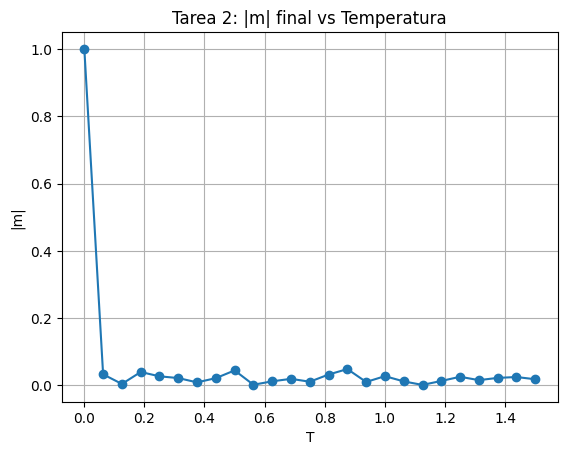

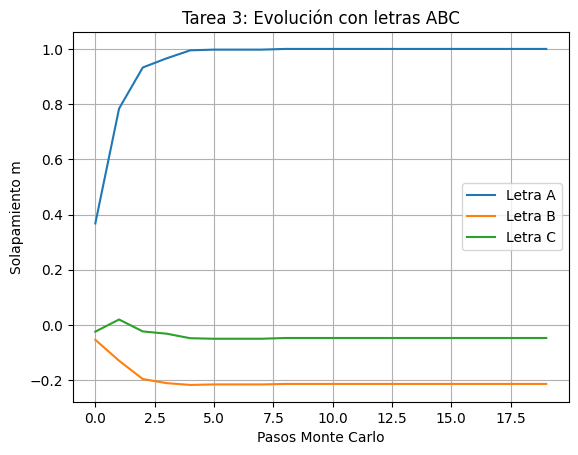

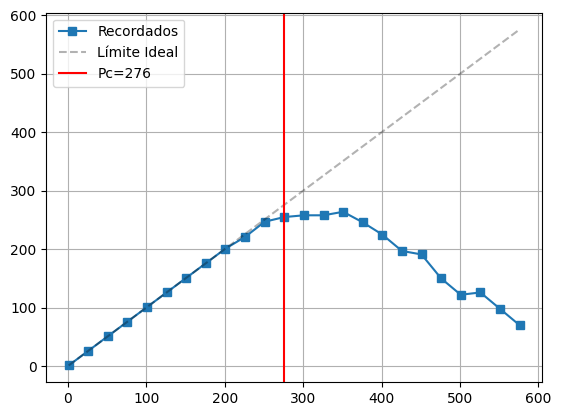

In [16]:

def run_all_tasks():
    T_low = 1e-4

    # --- TAREA 1: ANIMACIÓN (N=50) ---

    # Muestra cómo una red recupera un patrón en cruz partiendo de un estado aleatorio

    print("Generando GIF de la Tarea 1...")
    N1 = 50
    p1 = np.zeros((N1, N1))
    p1[N1//2-2:N1//2+2, :] = 1
    p1[:, N1//2-2:N1//2+2] = 1 # Patrón en cruz
    net1 = HopfieldNet(N1)
    net1.store_patterns([p1])
    state = np.random.randint(0, 2, (N1, N1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    im = ax1.imshow(state, cmap='binary')
    line, = ax2.plot([], [], 'r-')
    ax2.set_xlim(0, 20); ax2.set_ylim(-1.1, 1.1)
    ax2.set_title("Solapamiento m(t)")
    ax2.grid(True)
    m_hist = []

    def update(frame):
        nonlocal state
        m_hist.append(net1.overlap(state, 0))
        im.set_data(state)
        line.set_data(range(len(m_hist)), m_hist)
        state = net1.metropolis_step(state, T_low)
        return im, line

    ani = FuncAnimation(fig, update, frames=21, blit=True)
    ani.save(os.path.join(PATH, "evolucion_hopfield.gif"), writer='pillow')
    plt.close()

    # --- TAREA 2: INFLUENCIA DE LA TEMPERATURA ---

    # Representa el sistema a distintas temperaturas para ver el momento en el que
    # la red pasa de un estado de "memoria" a una fase de "ruido."
    print("Ejecutando Tarea 2: Solapamiento vs Temperatura...")
    temps = np.linspace(0.001, 1.5, 25)
    m_finales = []
    for t in temps:
        s_t = p1.copy()
        # Evolucionamos 15 pasos para alcanzar el equilibrio térmico
        for _ in range(15):
            s_t = net1.metropolis_step(s_t, t)
        m_finales.append(abs(net1.overlap(s_t, 0)))

    plt.figure()
    plt.plot(temps, m_finales, 'o-')
    plt.title("Tarea 2: |m| final vs Temperatura")
    plt.xlabel("T"); plt.ylabel("|m|")
    plt.grid(); plt.savefig(os.path.join(PATH, "tarea2_m_vs_T.png"))
    print(f"Gráfica guardada en {PATH}")

    # --- TAREA 3: INTERACCIÓN CON EL USUARIO (N=30) ---

    # El usuario elige 3 letras, y la red las almacena simultáneamente.
    # Deformamos la red un 30% para ver si la red es capaz de identificarla
    #correctamente de los demás recuerdos.
    print("\n--- INICIANDO TAREA 3 ---")
    N3 = 30
    dict_letras = obtener_diccionario_letras(N3)

    while True:
        entrada = input("Introduce 3 letras de la A a la Z (ej: ABC): ").upper()
        if len(entrada) == 3 and all(c in dict_letras for c in entrada):
            break
        print("Entrada no válida. Por favor, introduce exactamente 3 letras.")

    letras_elegidas = [dict_letras[c] for c in entrada]
    net3 = HopfieldNet(N3)
    net3.store_patterns(letras_elegidas) # Almacenamos varios patrones a la vez

    # Partimos de la primera letra elegida deformada un 30%
    print(f"Simulando recuperación de la letra '{entrada[0]}'...")
    s_test = letras_elegidas[0].copy()
    ruido = np.random.rand(N3, N3) < 0.3
    s_test[ruido] = 1 - s_test[ruido]

    m_hist_3 = {i: [] for i in range(3)}
    for _ in range(20):
        for i in range(3):
            m_hist_3[i].append(net3.overlap(s_test, i))
        s_test = net3.metropolis_step(s_test, T_low)

    plt.figure()
    for i in range(3):
        plt.plot(m_hist_3[i], label=f"Letra {entrada[i]}")
    plt.title(f"Tarea 3: Evolución con letras {entrada}")
    plt.xlabel("Pasos Monte Carlo"); plt.ylabel("Solapamiento m")
    plt.legend(); plt.grid()
    plt.savefig(os.path.join(PATH, "tarea3_letras_usuario.png"))
    print(f"Gráfica guardada en {PATH}")

    # --- TAREA 4: CAPACIDAD (N=20) ---

    # Buscamos el límite de la red. Introducimos patrones aleatorios hasta
    # que la red subre amnesia catastrófica.

    print("\nCalculando Tarea 4: Capacidad Crítica...")
    N4 = 20
    P_vals = np.arange(1, 601, 25) # Patrones aleatorios para estresar la red [cite: 31, 32]
    recuperados = []
    Pc = 0
    for P in P_vals:
        p_list = [(np.random.rand(N4, N4) > 0.5).astype(int) for _ in range(P)]
        net4 = HopfieldNet(N4)
        net4.store_patterns(p_list)
        count = sum(1 for mu in range(P) if net4.overlap(net4.metropolis_step(p_list[mu].copy(), T_low), mu) > 0.75)
        recuperados.append(count)
        if count >= P * 0.9: Pc = P

    alpha_c = Pc / (N4*N4) # alpha_c = Pc / N^2 fracción máxima
    print(f"Resultado T4: alpha_c = {alpha_c:.4f}")

    plt.figure()
    plt.plot(P_vals, recuperados, 's-', label="Recordados")
    plt.plot(P_vals, P_vals, '--k', alpha=0.3, label="Límite Ideal")
    plt.axvline(x=Pc, color='r', label=f'Pc={Pc}')
    plt.legend(); plt.grid()
    plt.savefig(os.path.join(PATH, "tarea4_capacidad.png"))

if __name__ == "__main__":
    run_all_tasks()

**5. Conclusiones y Análisis de Resultados**

Tras la simulación, podemos extraer las siguientes conclusiones sobre la red neuronal y la memoria asociativa:

**Tarea 1**

La red demostró ser un sistema robusto, capaz de recuerar información de datos incompletos. La convergencia al solapamiento m=1 para el patrón deformado al 30% confirma que los patrones actúan como atractores globales. La convergencia a m=-1 es un resultado equivalente al caso anterior. Debido a la simetría $s_i \leftrightarrow (1-s_i)$, el antipatrón posee la misma energía mínima que el patrón original.

**Tarea 2**

El estudio del solapamiento frente a la temperatura revela una transición de fase. A bajas temperaturas, el sistema mantiene una fase ordenada de memoria. Al ir aumentándola, el ruido térmico introducido por el algoritmo de Metrópolis hace que, por encima de una temperatura crítica (desplome de la curva), la red entra en una fase desordenada paramagnética, donde la capacidad de recupración es prácticamente nula.

**Tarea 3**

Al probar con una combinación como "AFX", observamos que la red recupera exitosamente la letra objetivo (A), y mantiene interferencia mínima con patrones como la F. El solapamiento residual observado con la letra X es una medida de la correlación espacial entre las letras (similitud en las diagonales).

**Tarea 4**

Se identifica el punto de colapso en $P_c=276$ patrones, arrojando un valor de la capacidad crítica de $\alpha_c = 0.6900$. Graficamente, observamos con claridad el punto de amnesia catastrófica. Una vez superada la carga crítica, se pierde totalmente la capacidad de memoria.